# Master PCA Runner
Loads processed bundle data and runs all PCA plot families from `pca_plotting.py`.


## Imports
Loads prep/plot modules plus basic libraries used for config and quick checks.


In [199]:
from pathlib import Path
import importlib
import numpy as np
import pandas as pd

import pca_data_prep as prep
import pca_plotting as plots
import verify_data as verify

# Always reload local modules so notebook uses latest patched code.
prep = importlib.reload(prep)
plots = importlib.reload(plots)

print('pca_data_prep path:', Path(prep.__file__).resolve())
if not hasattr(prep, 'extract_probe_letters'):
    raise AttributeError(
        'Loaded pca_data_prep does not expose extract_probe_letters. '
        'Restart kernel and re-run this cell, then confirm it points to master/pca_data_prep.py.'
    )


pca_data_prep path: C:\Users\user\Documents\github\PCA_on_neural_data\master\pca_data_prep.py


#### ======================================================================================================================================================================================================================================
## Manually set all 6 paths
#### ======================================================================================================================================================================================================================================


In [200]:
# SET #1: Path to the NWB file for this session (on the neural data computer)
NWB_PATH = Path(r"G:\Grant\neuropixels\nwb\Reach15")

# SET #2: Path to the bombcell root folder for this session (on the neural data computer)
BOMBCELL_ROOT_FOR_AUTO_BUILD = Path(r"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618")

# SET #3: Session name (for labeling plots)
SESSION_NAME = Path(r'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00')

# SET #4: Paths to trial index files (these are from the behavior video acquisition computer, not the neural data computer)
baseline_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_baseline_trial_numbers_tone2_aligned.npy"
washout_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_washout_trial_numbers_tone2_aligned.npy"
optoicalStim_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_stim_allowed_trial_numbers_tone2_aligned.npy"


#### Veirfy all 6 Manually set paths exist in their correct FULL form before attempting to load them in

In [201]:
# SET #1: Validate NWB file path  
if not NWB_PATH.exists():
    raise FileNotFoundError(f"NWB file not found at {NWB_PATH}. Please check the path and try again.")

# SET #2: Validate bombcell root path and expected folder structure
FULL_BOMBCELL_PATH = BOMBCELL_ROOT_FOR_AUTO_BUILD / "kilosort4_A" / "bombcell"
if not FULL_BOMBCELL_PATH.exists():
    raise FileNotFoundError(
        f"Expected to find bombcell data at {FULL_BOMBCELL_PATH}, but it does not exist. "
        "Please check that BOMBCELL_ROOT_FOR_AUTO_BUILD is set correctly and that the folder structure matches the expected format."
    )


# SET #3: Validate the NP session name and construct paths to data, with error handling
FULL_SESSION_PATH = r'H:\Grant\Neuropixels\Kilosort_Recordings' / SESSION_NAME
if not FULL_SESSION_PATH.exists():
    raise FileNotFoundError(
        f"Expected to find session data at {FULL_SESSION_PATH}, but it does not exist. "
        "Please check that SESSION_NAME is set correctly and that the folder structure matches the expected format."
    )


# SET #4: Validate trial index file paths
if not Path(baseline_trials_index_path).exists():
    raise FileNotFoundError(f"Baseline trials index file not found at {baseline_trials_index_path}. Please check the path and try again.")
if not Path(washout_trials_index_path).exists():
    raise FileNotFoundError(f"Washout trials index file not found at {washout_trials_index_path}. Please check the path and try again.")
if not Path(optoicalStim_trials_index_path).exists():
    raise FileNotFoundError(f"Optical stim trials index file not found at {optoicalStim_trials_index_path}. Please check the path and try again.")


#### =======================================================================================================================================================================================================================================
## Begin loading and processing data
#### =======================================================================================================================================================================================================================================


### SETS #1 & #2: Load (NWB + Bombcell) & Load or Auto-Build Processed Bundle
Loads `merged_dic`, `stim_df`, and `pca_event_meta` from `processed_data/bundle_latest`.
If the bundle is missing, this cell can auto-build it from an NWB file for the current recording.

In [202]:
bundle, merged_dic, stim_df, df_stim, pca_event_meta, extras, meta, PROCESSED_BUNDLE_DIR = prep.load_or_build_processed_bundle(
    nwb_path_for_auto_build=NWB_PATH,
    bombcell_root_for_auto_build="",
    use_bombcell_if_available=True,
    auto_build_bundle_if_missing=True,
    auto_rebuild_if_bombcell_missing=True,
    required_filenames=("merged_dic.pkl", "stim_df.pkl", "pca_event_meta.pkl"),
    verbose=True,
)

print('\n\n NOTE: pca_event_meta key will be WRONG at this point. it gets properly built during the prep.build_pca_event_meta_and_event_times(...) call in a later cell')

Bombcell root not set. Set bombcell_root_for_auto_build to merge in_brainRegion/brain_region/bc_label.
Loaded bundle: processed_data\bundle_latest
Meta: {'created_at': '2026-02-27T17:36:14.067584', 'files': ['merged_dic.pkl', 'stim_df.pkl', 'pca_event_meta.pkl', 'extras.pkl'], 'n_probes': 6, 'n_events_stim_df': 1352824, 'n_events_pca_meta': 1352824}
pca_event_meta rows: 1352824


 NOTE: pca_event_meta key will be WRONG at this point. it gets properly built during the prep.build_pca_event_meta_and_event_times(...) call in a later cell


### SET #3: Load Neuropixel Session Root & Create Save Dir for Plots

In [203]:
FULL_SESSION_PATH = r'H:\Grant\Neuropixels\Kilosort_Recordings' / SESSION_NAME
PLOTS_SAVE_ROOT = FULL_SESSION_PATH / "analysis" / "PCA"

if PLOTS_SAVE_ROOT.exists():
    print(f"Save directory exists: {PLOTS_SAVE_ROOT}")
else:
    print(f"Save directory did not exist, creating: {PLOTS_SAVE_ROOT}")
    PLOTS_SAVE_ROOT.mkdir(parents=True, exist_ok=True)


Save directory exists: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\PCA


### SET #4: Loads the trial index files 

In [204]:
baseline_trials_idx = np.load(baseline_trials_index_path, allow_pickle=True)
washout_trials_idx = np.load(washout_trials_index_path, allow_pickle=True)
optoicalStim_trials_idx = np.load(optoicalStim_trials_index_path, allow_pickle=True)

### Fix the pca_events_meta dataframe and load in all stimulus start_times as arrays

In [205]:
pca_event_meta, tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times = prep.build_pca_event_meta_and_event_times(
    stim_df=stim_df,
    baseline_trials_idx=baseline_trials_idx,
    optoicalStim_trials_idx=optoicalStim_trials_idx,
    washout_trials_idx=washout_trials_idx
)

#### =======================================================================================================================================================================================================================================
## Verify Loaded Data
#### =======================================================================================================================================================================================================================================


#### CHECK #1 - that the trial numbers and structure for baseline, stimulation, and washout trials are correct
- if the structure of any epoch is WRONG will fix the structure if its incorrect

Total Baseline Trials:  20
Total Washout epochs:  5
Total Optical Stim epochs:  5

baseline_trials_idx [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
optoicalStim_trials_idx [list([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
 list([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])
 list([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120])
 list([141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160])
 list([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270])]
washout_trials_idx [list([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])
 list([81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92

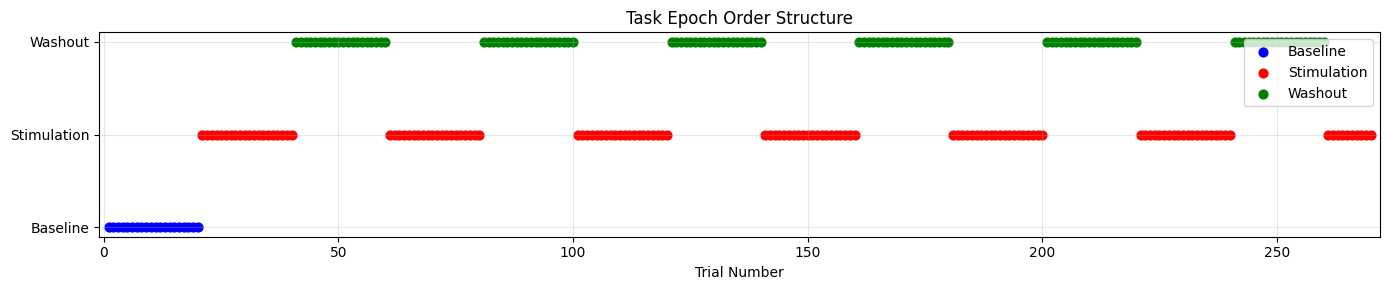

Epoch summaries (trial indices as used for verification):
  Baseline: 1..20 (n=20)
  Stim 1:  21..40 (n=20)
  Stim 2:  61..80 (n=20)
  Stim 3:  101..120 (n=20)
  Stim 4:  141..160 (n=20)
  Stim 5:  181..200 (n=20)
  Stim 6:  221..240 (n=20)
  Stim 7:  261..270 (n=10)
  Wash 1:  41..60 (n=20)
  Wash 2:  81..100 (n=20)
  Wash 3:  121..140 (n=20)
  Wash 4:  161..180 (n=20)
  Wash 5:  201..220 (n=20)
  Wash 6:  241..260 (n=20)

WARNINGS:
 - Stim epochs (7) != Wash epochs (6); checking first 6 pairs.

FAILED checks:
 - Stim epoch 7 size = 10 (expected 20).
 - Stim epochs = 7 (expected 5).
 - Wash epochs = 6 (expected 5).


In [206]:
result = verify.verify_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_per_epoch=20,
    expect_stim_epochs=5,
    expect_wash_epochs=5,
    auto_split_merged_epochs=True,
    split_mode="keep_incomplete",  # "raise" | "drop_incomplete" | "keep_incomplete"
    show_plot=True,
    verbose=True
)
# Overwrite with correct structure expected downstream
og_baseline_trials_idx = baseline_trials_idx
og_optoicalStim_trials_idx = optoicalStim_trials_idx
og_washout_trials_idx = washout_trials_idx

baseline_trials_idx = result["used_epochs"]["baseline"]
optoicalStim_trials_idx = result["used_epochs"]["stim"]
washout_trials_idx = result["used_epochs"]["wash"]

### Post epoch modification verification (cell above modified these indexs if needed)

In [207]:
# verify these events are correct it should go Baseline -> Optical Stim -> Washout (with 20 trials in each epoch)
print('Total Baseline Trials: ', len(baseline_trials_idx))
print('Total Washout epochs: ', len(washout_trials_idx))
print('Total Optical Stim epochs: ', len(optoicalStim_trials_idx))
print('')
print('baseline_trials_idx',baseline_trials_idx)
print('')
print('optoicalStim_trials_idx',optoicalStim_trials_idx)
print('')
print('washout_trials_idx',washout_trials_idx)

Total Baseline Trials:  1
Total Washout epochs:  6
Total Optical Stim epochs:  7

baseline_trials_idx [[1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20]]

optoicalStim_trials_idx [list([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
 list([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])
 list([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120])
 list([141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160])
 list([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200])
 list([221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240])
 list([261, 262, 263, 264, 265, 266, 267, 268, 269, 270])]

washout_trials_idx [[41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60]
 [81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100]
 [12

### Rebuild pca_event_meta with correct trial structure and check timing of stim events again

In [208]:
pca_event_meta, tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times = prep.build_pca_event_meta_and_event_times(
    stim_df=stim_df,
    baseline_trials_idx=baseline_trials_idx,
    optoicalStim_trials_idx=optoicalStim_trials_idx,
    washout_trials_idx=washout_trials_idx
)

### CHECK #2: the time between stim events and task events is reasonable (e.g. not hours apart, which would suggest a mismatch in trial indexing)

In [209]:
# To see the time between each indidual stim event set show_detailed_output=True
stim_timing_dic = verify.check_stim_event_timing(df_stim,max_window=4,show_detailed_output=False)

=== Average time differences between events (valid pairs within expected window): ===

---- Expected ~2 s -----
tone1 and tone2:  1.43 (270 pairs)

---- These two should be similar -----
tone1 and stimROI:              1.75 (130 pairs)
tone1 and all_stimROI_triggers: 1.7 (270 pairs)

---- These two should be similar -----
tone2 and stimROI:              0.32 (127 pairs)
tone2 and all_stimROI_triggers: 0.32 (245 pairs)

---- Should be near zero -----
all_stimROI_triggers and stimROI: 0.04 (130 pairs)


### CHECK 3: probe keys, table shapes, and key columns before running PCA plots.


In [210]:
print("Probes:", sorted(list(merged_dic.keys())))
PCA_SELECTED_PROBES = sorted(list(merged_dic.keys()))
print("PCA_SELECTED_PROBES:", PCA_SELECTED_PROBES)
print("stim_df shape:", stim_df.shape)
print("pca_event_meta shape:", pca_event_meta.shape)
print("pca_event_meta columns:", list(pca_event_meta.columns))

first_probe = sorted(list(merged_dic.keys()))[0]
print("\nExample probe:", first_probe)
print("units:", len(merged_dic[first_probe]))
print("columns:", list(merged_dic[first_probe].columns))

if "brain_region" in merged_dic[first_probe].columns:
    print("brain_region unique:", pd.Series(merged_dic[first_probe]["brain_region"]).dropna().astype(str).unique()[:20])

pca_event_meta.head(3)

# quick Bombcell merge check per probe
for _p in sorted(list(merged_dic.keys())):
    _cols = set(merged_dic[_p].columns)
    print(f"Probe {_p}: in_brainRegion={'in_brainRegion' in _cols}, brain_region={'brain_region' in _cols}, bc_label={'bc_label' in _cols}")


Probes: ['A', 'B', 'C', 'D', 'E', 'F']
PCA_SELECTED_PROBES: ['A', 'B', 'C', 'D', 'E', 'F']
stim_df shape: (1352824, 10)
pca_event_meta shape: (270, 6)
pca_event_meta columns: ['trial_index0', 'trial_number', 'start_time', 'condition', 'epoch_id', 'condition_epoch']

Example probe: A
units: 554
columns: ['depth', 'xpos', 'ypos', 'label', 'KSlabel', 'KSamplitude', 'KScontamination', 'probe', 'spike_times', 'cluster_id', 'nSpikes', 'maxDriftEstimate', 'maxChannels', 'bc_label', 'in_brainRegion', 'brain_region']
brain_region unique: ['SIM' 'IP']
Probe A: in_brainRegion=True, brain_region=True, bc_label=True
Probe B: in_brainRegion=True, brain_region=True, bc_label=True
Probe C: in_brainRegion=True, brain_region=True, bc_label=True
Probe D: in_brainRegion=True, brain_region=True, bc_label=True
Probe E: in_brainRegion=True, brain_region=True, bc_label=True
Probe F: in_brainRegion=True, brain_region=True, bc_label=True


### CHECK #4: the two main dictionaries are loaded in correctly and contain expected keys/columns

##### 1. merged_dic contains all the unit data

In [211]:
probe = 'A'
merged_dic[probe][0:3]

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,in_brainRegion,brain_region
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,"[9938.427594575005, 9938.443329123113, 9938.44...",0,14579.0,29.717560,52,NOISE,IN_ROI,SIM
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,"[9938.363989665882, 9938.408826460065, 9938.42...",1,35469.0,93.164818,52,NOISE,IN_ROI,SIM
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,"[9938.135738714089, 9939.27045963741, 9940.801...",2,176.0,4.297394,5,NOISE,IN_ROI,SIM


##### 1. pca_event_meta contains all the event/stimulus data

In [212]:
pca_event_meta

,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
0,0,1,10239.893300,baseline,0,baseline_epoch
1,1,2,10263.343867,baseline,0,baseline_epoch
2,2,3,10285.494367,baseline,0,baseline_epoch
3,3,4,10306.931567,baseline,0,baseline_epoch
4,4,5,10383.171333,baseline,0,baseline_epoch
...,...,...,...,...,...,...
265,265,266,18693.912033,stimulation,7,stimulation_epoch_7
266,266,267,18714.177167,stimulation,7,stimulation_epoch_7
267,267,268,18743.100500,stimulation,7,stimulation_epoch_7
268,268,269,18764.043367,stimulation,7,stimulation_epoch_7


In [213]:
condition_epoch_names = pca_event_meta['condition_epoch'].unique()
print("Condition epoch names in pca_event_meta:", condition_epoch_names)

Condition epoch names in pca_event_meta: ['baseline_epoch' 'stimulation_epoch_1' 'washout_epoch_1'
 'stimulation_epoch_2' 'washout_epoch_2' 'stimulation_epoch_3'
 'washout_epoch_3' 'stimulation_epoch_4' 'washout_epoch_4'
 'stimulation_epoch_5' 'washout_epoch_5' 'stimulation_epoch_6'
 'washout_epoch_6' 'stimulation_epoch_7']


#### ================================================================================================================================================================================================================================================================================================
## Sinlge Probe Plot Config
#### ================================================================================================================================================================================================================================================================================================
Sets output root, PCA binning, filters, and smoothing used by all plot calls.


In [227]:
WINDOW_START_S = -1.5
WINDOW_END_S = 1.5
BIN_SIZE_S = 0.025
MAX_TENSOR_GB = 8.0
N_COMPONENTS = 12
SMOOTH_SIGMA = 1.5

PLOT_COLOR_MODE = 2  # 1=regular shared epoch colors, 2=stim blue + wash red gradients, 3=gray base + condition highlight for first MODE3_HIGHLIGHT_WINDOW_S seconds
STIMULATION_LINESTYLE = ":"
WASHOUT_LINESTYLE = "-"
BASELINE_LINESTYLE = "-"
BASELINE_COLOR = "orange"

# Mode 3: Select the highlight window for each epoch (e.g. 0-500ms) and the color to use for that highlight, while the rest of the epoch is a more neutral color
MODE3_HIGHLIGHT_WINDOW_S = 0.5
MODE3_HIGHLIGHT_COLOR = "green"  # fallback only for unknown condition labels
# Mode 3: Select the base color for the non-highlight portion of each epoch
MODE3_BASE_COLOR = "gray"
# Mode 3: Select Highlight color for 0-500ms for each epoch 
MODE3_STIMULATION_COLOR = "purple"
MODE3_WASHOUT_COLOR = "green"
MODE3_BASELINE_COLOR = "orange"

plots.set_epoch_plot_style(
    color_mode=PLOT_COLOR_MODE,
    stimulation_linestyle=STIMULATION_LINESTYLE,
    washout_linestyle=WASHOUT_LINESTYLE,
    baseline_linestyle=BASELINE_LINESTYLE,
    baseline_color=BASELINE_COLOR,
    mode3_base_color=MODE3_BASE_COLOR,
    mode3_stimulation_color=MODE3_STIMULATION_COLOR,
    mode3_washout_color=MODE3_WASHOUT_COLOR,
    mode3_baseline_color=MODE3_BASELINE_COLOR,
    mode3_highlight_color=MODE3_HIGHLIGHT_COLOR,
    mode3_highlight_window_s=MODE3_HIGHLIGHT_WINDOW_S,
)


EPOCH_PCA_PROBE = "C"
EPOCH_PCA_BRAIN_REGION = None   # None => first available region after filtering
EPOCH_PCA_ROI_FILTER = "IN_ROI"  # None, "IN_ROI", "OUT_ROI"
EPOCH_PCA_KSLABEL_FILTER = "both"  # "both", "good", "mua"
EPOCH_PCA_BC_LABEL_FILTER = ["GOOD", "MUA"]  # "all" or subset like "GOOD" / ["GOOD", "MUA"]
EPOCH_PCA_INCLUDE_CONDITIONS = ["baseline", "stimulation", "washout"]
EPOCH_PCA_FILTER_TYPE = "bombcell"  # "bombcell" or "kilosort"

_filter_type_norm = str(EPOCH_PCA_FILTER_TYPE).strip().lower()
if _filter_type_norm not in {"bombcell", "kilosort"}:
    raise ValueError(f"Invalid EPOCH_PCA_FILTER_TYPE={EPOCH_PCA_FILTER_TYPE}. Use 'bombcell' or 'kilosort'.")
if _filter_type_norm == "bombcell":
    EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER = "both"
    EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER = EPOCH_PCA_BC_LABEL_FILTER
else:
    EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER = EPOCH_PCA_KSLABEL_FILTER
    EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER = "all"
print(f"Filter type={EPOCH_PCA_FILTER_TYPE} | effective KS={EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER} | effective BC={EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER}")

# Pick which event to align PCA windows to.
# Options: 'start_time', 'tone1_start_times', 'tone2_start_times',
#          'stimROI_start_times', 'optical_start_times', 'all_stimROI_triggers_start_times'
EVENT_TIME_ALIGN_TO = "tone2_start_times"
# 'index' | 'nearest' | 'index_then_nearest'
EVENT_TIME_ALIGN_MISMATCH = "index_then_nearest"
# None disables cutoff. Otherwise, nearest matches farther than this are dropped.
EVENT_TIME_ALIGN_MAX_DELTA_S = None
EVENT_TIME_DROP_UNMATCHED = True

pca_event_meta_aligned, EVENT_TIME_ALIGN_REPORT = prep.align_pca_event_meta_start_times(
    pca_event_meta=pca_event_meta,
    align_to=EVENT_TIME_ALIGN_TO,
    tone1_start_times=tone1_start_times,
    tone2_start_times=tone2_start_times,
    stimROI_start_times=stimROI_start_times,
    optical_start_times=optical_start_times,
    all_stimROI_triggers_start_times=all_stimROI_triggers_start_times,
    mismatch=EVENT_TIME_ALIGN_MISMATCH,
    max_delta_s=EVENT_TIME_ALIGN_MAX_DELTA_S,
    drop_unmatched=EVENT_TIME_DROP_UNMATCHED,
)
print("event-time alignment:", EVENT_TIME_ALIGN_REPORT)

SHOW_PLOTS_SINGLE = True
SHOW_PLOTS_BATCH = False

PLOTS_SAVE_PATH = PLOTS_SAVE_ROOT/ 'byEpoch' / f"mode_{PLOT_COLOR_MODE}"
print('plots will be saved to:', PLOTS_SAVE_PATH)

Filter type=bombcell | effective KS=both | effective BC=['GOOD', 'MUA']
event-time alignment: {'source': 'tone2_start_times', 'method': 'index_then_nearest', 'used_index': True, 'input_rows': 270, 'output_rows': 270, 'unmatched_rows': 0}
plots will be saved to: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\PCA\byEpoch\mode_2


#### Build Single Probe Inputs + Scree Plot
Filters units by probe/ROI/KS/brain_region, bins spikes around epoch events, and computes trial-level PCA.


Requested tensor shape=(270, 171, 120) est_mem=0.02 GB
Events: 270 Units: 171
EVR first 5: [0.2293 0.0958 0.0432 0.0399 0.0342]
brain_region: MoP


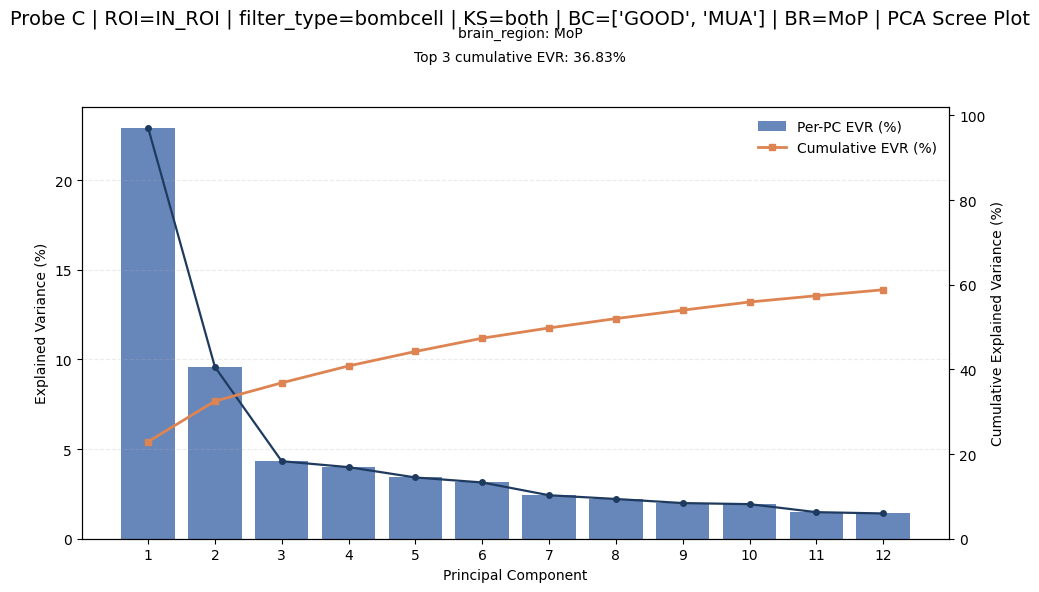

In [228]:
_available_regions = plots._list_probe_brain_regions(
    merged_dic=merged_dic,
    probe=EPOCH_PCA_PROBE,
    roi_filter=EPOCH_PCA_ROI_FILTER,
    kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
    bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
)
if len(_available_regions) == 0:
    raise ValueError(f"No brain regions found for probe {EPOCH_PCA_PROBE} after ROI/KS/BC filtering.")

if EPOCH_PCA_BRAIN_REGION is None:
    EPOCH_PCA_BRAIN_REGION = _available_regions[0]

if EPOCH_PCA_BRAIN_REGION not in _available_regions:
    raise ValueError(f"brain_region {EPOCH_PCA_BRAIN_REGION} not available. Available: {_available_regions}")

event_meta_probe, trials_ec, time_ec, Xp_ec, evr_ec = plots.run_epoch_condition_pca_for_probe(
    probe=EPOCH_PCA_PROBE,
    merged_dic=merged_dic,
    event_meta=pca_event_meta_aligned,
    roi_filter=EPOCH_PCA_ROI_FILTER,
    kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
    bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
    include_conditions=EPOCH_PCA_INCLUDE_CONDITIONS,
    n_components=max(3, N_COMPONENTS),
    max_tensor_gb=MAX_TENSOR_GB,
    win_start_s=WINDOW_START_S,
    win_end_s=WINDOW_END_S,
    bin_size_s=BIN_SIZE_S,
    brain_region_filter=EPOCH_PCA_BRAIN_REGION,
)

plot_title = f"Probe {EPOCH_PCA_PROBE} | ROI={EPOCH_PCA_ROI_FILTER} | filter_type={EPOCH_PCA_FILTER_TYPE} | KS={EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER} | BC={EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER} | BR={EPOCH_PCA_BRAIN_REGION}"
brain_region_subtitle = plots.probe_brain_region_label(
    merged_dic=merged_dic,
    probe=EPOCH_PCA_PROBE,
    roi_filter=EPOCH_PCA_ROI_FILTER,
    kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
    bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
)

print("Events:", len(event_meta_probe), "Units:", trials_ec.shape[1])
print("EVR first 5:", np.round(evr_ec[:5], 4))
print(brain_region_subtitle)

plots.plot_pca_scree(
    evr=evr_ec,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    run_label="epoch_condition",
    save_root=PLOTS_SAVE_ROOT,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Group 1: Base Trial-Level Epoch Plot Set
Creates one large figure with 3 subplots:
- 2D PC1/PC2 scatter
- 3D PC1/PC2/PC3 scatter
- 3D PC1/PC2/Time


In [229]:
print('You are about to run PCA on the following selection:')
EPOCH_PCA_PROBE,EPOCH_PCA_BRAIN_REGION, EPOCH_PCA_ROI_FILTER, EPOCH_PCA_FILTER_TYPE, EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER, EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER

You are about to run PCA on the following selection:


('C', 'MoP', 'IN_ROI', 'bombcell', 'both', ['GOOD', 'MUA'])

c:\Users\user\Documents\github\PCA_on_neural_data\master\pca_plotting.py:2991: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  


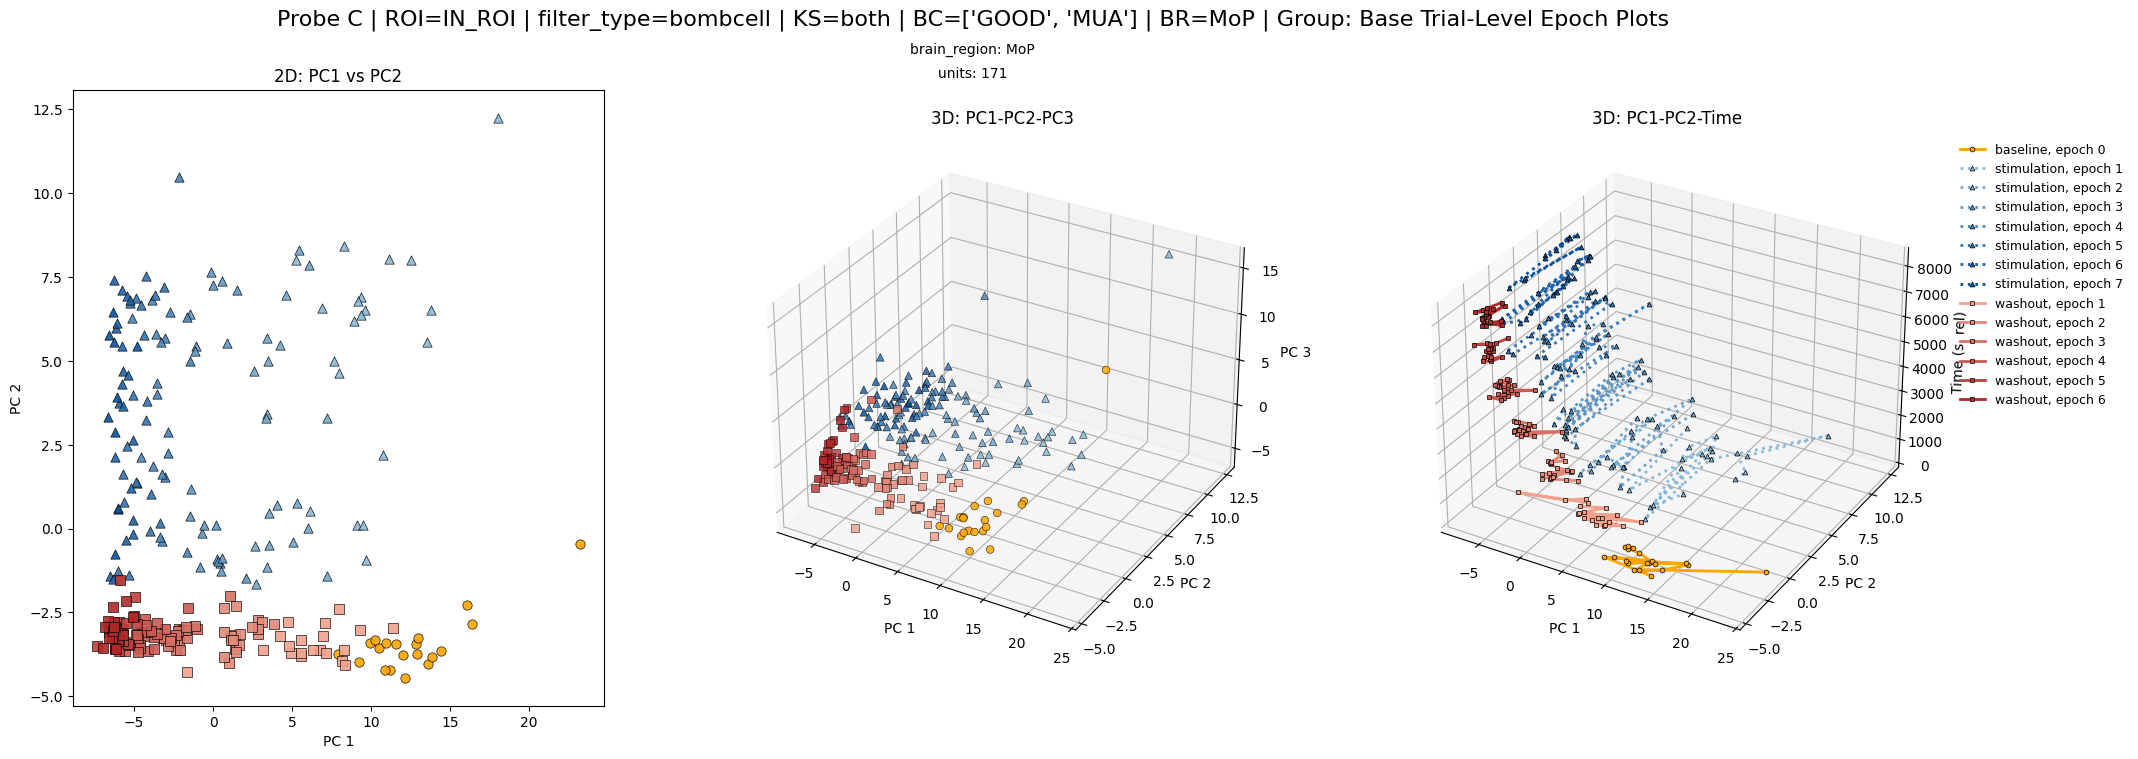

In [230]:
plots.set_epoch_plot_style(
    color_mode=PLOT_COLOR_MODE,
    stimulation_linestyle=STIMULATION_LINESTYLE,
    washout_linestyle=WASHOUT_LINESTYLE,
    baseline_linestyle=BASELINE_LINESTYLE,
    baseline_color=BASELINE_COLOR,
    mode3_base_color=MODE3_BASE_COLOR,
    mode3_stimulation_color=MODE3_STIMULATION_COLOR,
    mode3_washout_color=MODE3_WASHOUT_COLOR,
    mode3_baseline_color=MODE3_BASELINE_COLOR,
    mode3_highlight_color=MODE3_HIGHLIGHT_COLOR,
    mode3_highlight_window_s=MODE3_HIGHLIGHT_WINDOW_S,
)

plots.plot_epoch_condition_group_base_trial(
    Xp=Xp_ec,
    event_meta=event_meta_probe,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    time_col="start_time",
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_ROOT,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Group 2: Epoch-Mean Plot Set
Creates one large figure with 4 subplots:
- 2D epoch-mean
- 3D epoch-mean
- 3D epoch-mean PC1/PC2/Time points
- 3D epoch-mean PC1/PC2/Time lines


c:\Users\user\Documents\github\PCA_on_neural_data\master\pca_plotting.py:3114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  linestyle=_epoch_condition_linestyle_for(cond_linestyle, cond),


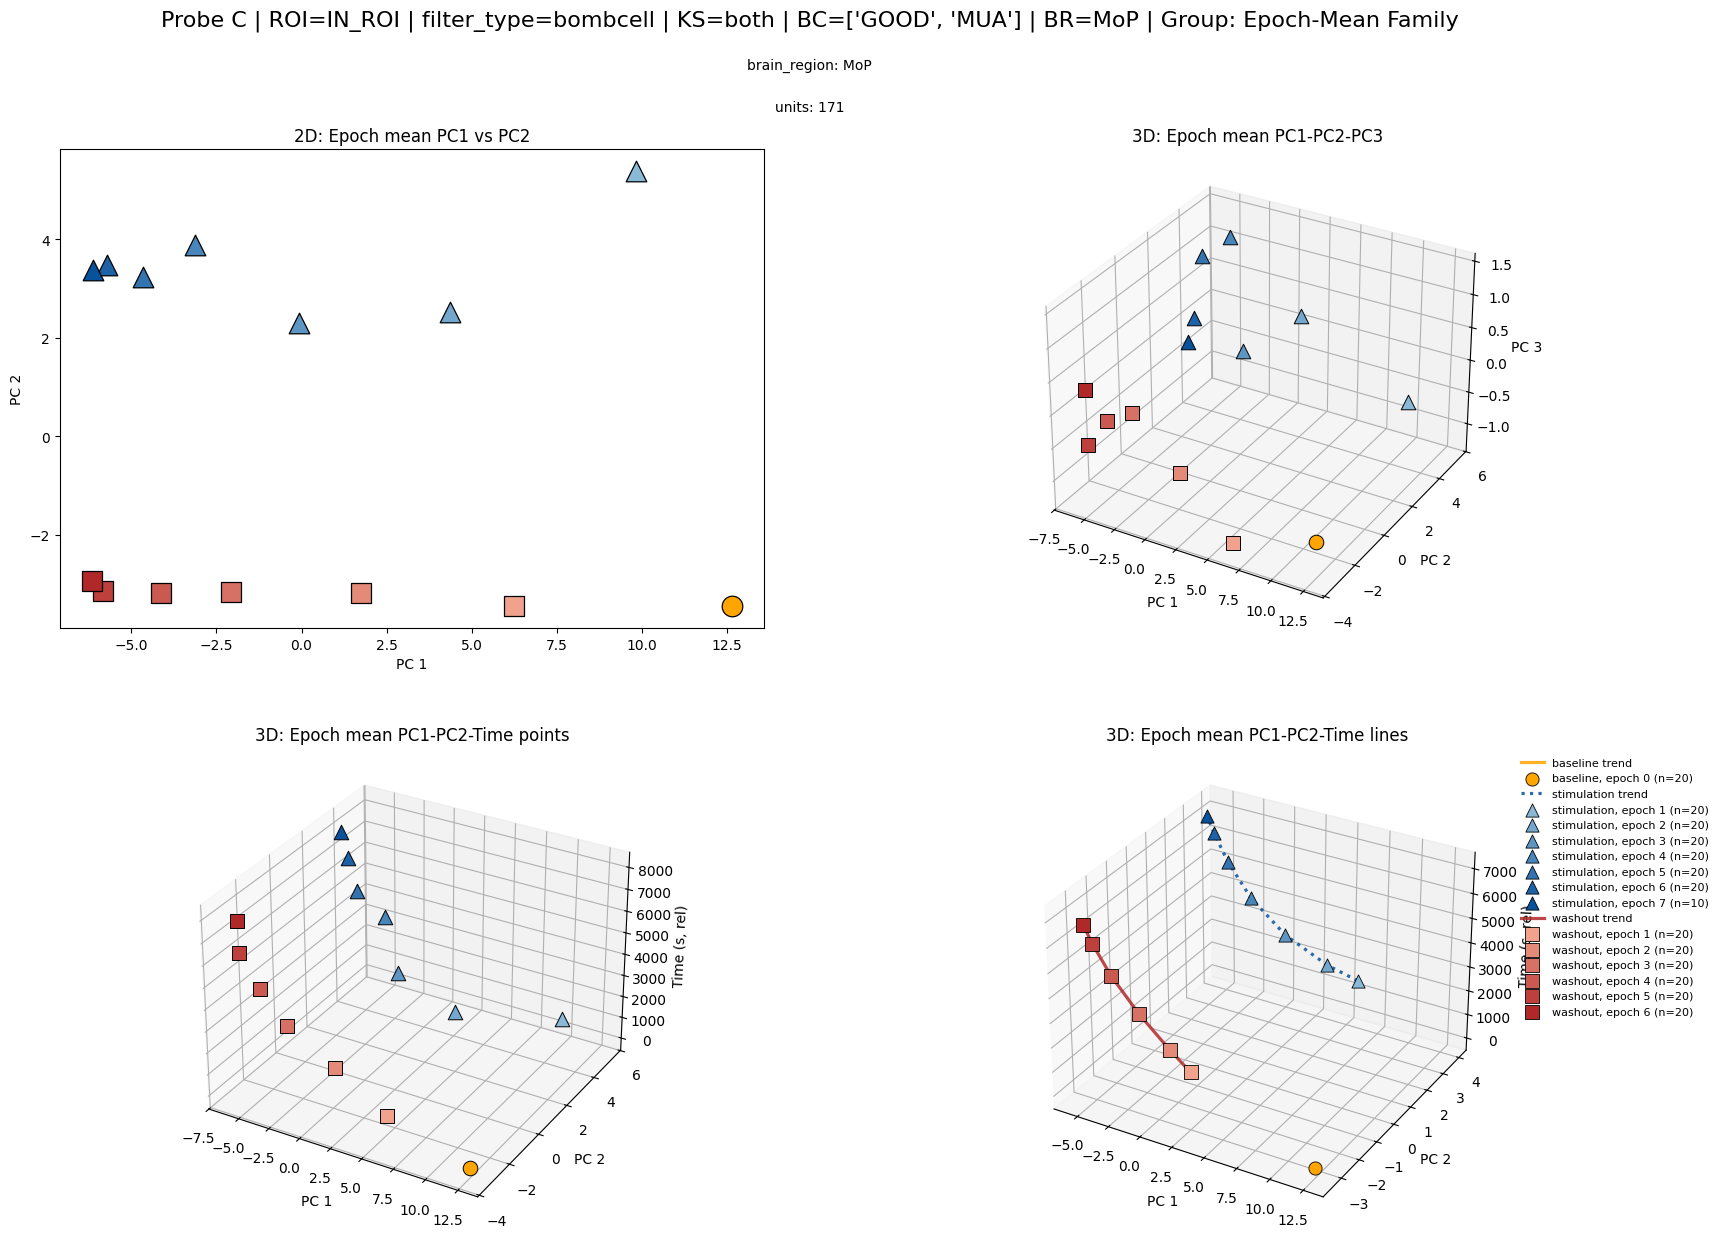

In [231]:
plots.plot_epoch_condition_group_epochmean(
    Xp=Xp_ec,
    event_meta=event_meta_probe,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    smooth_sigma=SMOOTH_SIGMA,
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_ROOT,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Group 3: Per-Trial Time-Bin Plot Set
Creates one large figure with 3 subplots from trial-level time-bin PCA trajectories:
- 2D lines
- 3D PC1/PC2/PC3 lines
- 3D PC1/PC2/Time lines


Trial-time PCA EVR first 5: [0.0947 0.0465 0.0308 0.0197 0.0179]


c:\Users\user\Documents\github\PCA_on_neural_data\master\pca_plotting.py:3246: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  style_ctx,


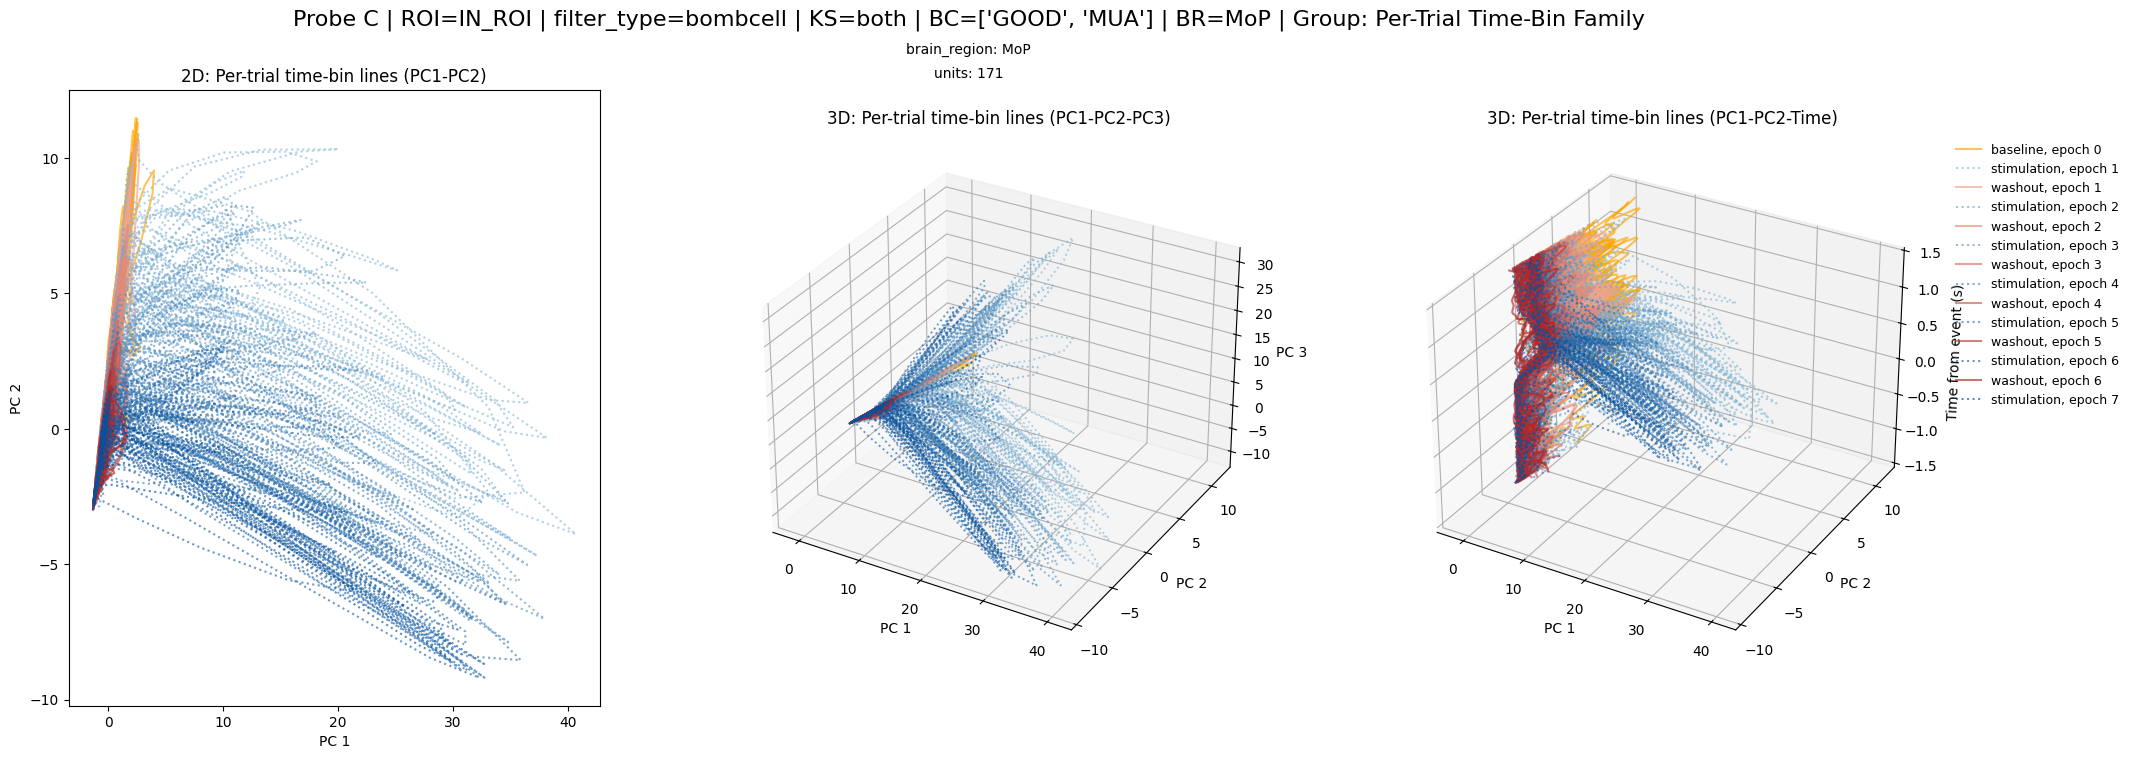

In [232]:
trial_time_scores, trial_time_evr = plots.pca_trial_timebin_scores(
    trials=trials_ec,
    n_components=max(3, N_COMPONENTS),
)
print("Trial-time PCA EVR first 5:", np.round(trial_time_evr[:5], 4))

plots.plot_epoch_condition_group_trial_time(
    trial_time_scores=trial_time_scores,
    event_meta=event_meta_probe,
    bin_time=time_ec,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    smooth_sigma=SMOOTH_SIGMA,
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_ROOT,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Group 4: One-Line-Per-Epoch Population Plot Set
Creates one large figure with 3 subplots from epoch-averaged population trajectories:
- 2D lines
- 3D PC1/PC2/PC3 lines
- 3D PC1/PC2/Time lines


Epoch-population PCA EVR first 5: [0.1977 0.1161 0.0609 0.0351 0.0216]


c:\Users\user\Documents\github\PCA_on_neural_data\master\pca_plotting.py:3376: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  marker=marker,


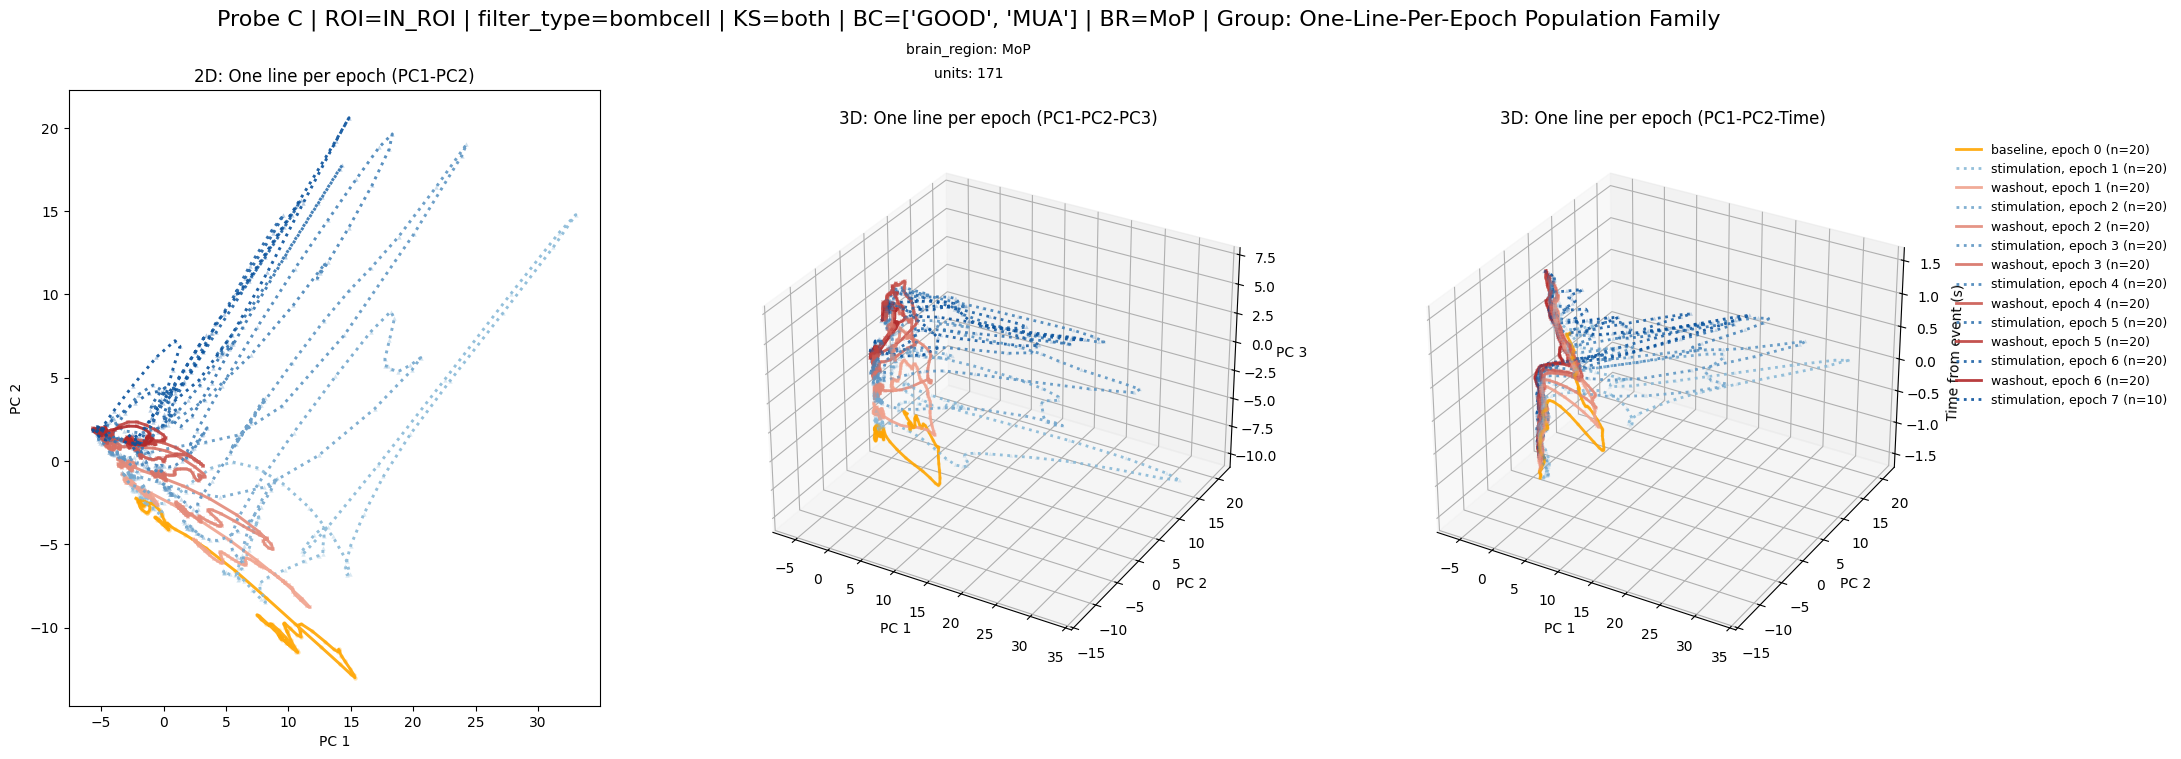

In [233]:
epoch_info_df, epoch_traj, epoch_evr = plots.pca_epoch_population_timebin_trajectories(
    trials=trials_ec,
    event_meta=event_meta_probe,
    n_components=max(3, N_COMPONENTS),
)
print("Epoch-population PCA EVR first 5:", np.round(epoch_evr[:5], 4))

plots.plot_epoch_condition_group_epoch_population(
    epoch_info_df=epoch_info_df,
    epoch_traj=epoch_traj,
    bin_time=time_ec,
    title_prefix=plot_title,
    subtitle=brain_region_subtitle,
    probe=EPOCH_PCA_PROBE,
    brain_region=EPOCH_PCA_BRAIN_REGION,
    smooth_sigma=SMOOTH_SIGMA,
    n_units=trials_ec.shape[1],
    save_root=PLOTS_SAVE_ROOT,
    show_plots=SHOW_PLOTS_SINGLE,
)


## Optional Legacy Individual Plot Calls
These are intentionally disabled to keep grouped workflow as default.


In [234]:
print("Grouped workflow is active. Individual legacy calls are disabled in this notebook version.")


Grouped workflow is active. Individual legacy calls are disabled in this notebook version.


## Optional Legacy Individual Plot Calls (continued)


In [235]:
print("Grouped workflow is active. Individual legacy calls are disabled in this notebook version.")


Grouped workflow is active. Individual legacy calls are disabled in this notebook version.


#### ==============================================================================================================================================================================================================================
## Batch PCA Run Config
#### ==============================================================================================================================================================================================================================


### 3 different plotting modes. all based on the coloring of the lines

Mode #1 = (Normal) where stimulation epoch #1 and Washout Epoch #1 share a color. same with Stimulation Epoch #2 and Washout Epoch #2

Mode #2 = (stim blue + washout red) All stimulation trials are BLUE and all washout trials are GREEN. There is a graident for each epoch, epoch #1 is lighter Blue or Green than Epoch #2 for example

Mode #3 = (Gray with 0-500ms green) All lines are GRAY, with stimultion trials remaining dotted, and wasout trials remaning solid lines. However, from event start_time to +500ms all lines are colored green. this should show the reach moment.  

#### How to select plotting mode:
 - PLOT_COLOR_MODE = 3  # 1=regular shared epoch colors, 2=stim blue + wash red gradients, 3=gray base + condition highlight for first MODE3_HIGHLIGHT_WINDOW_S seconds


In [236]:
pca_event_meta

,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
0,0,1,10239.893300,baseline,0,baseline_epoch
1,1,2,10263.343867,baseline,0,baseline_epoch
2,2,3,10285.494367,baseline,0,baseline_epoch
3,3,4,10306.931567,baseline,0,baseline_epoch
4,4,5,10383.171333,baseline,0,baseline_epoch
...,...,...,...,...,...,...
265,265,266,18693.912033,stimulation,7,stimulation_epoch_7
266,266,267,18714.177167,stimulation,7,stimulation_epoch_7
267,267,268,18743.100500,stimulation,7,stimulation_epoch_7
268,268,269,18764.043367,stimulation,7,stimulation_epoch_7


In [237]:
reachInit_stimROI = pca_event_meta.condition_epoch
print("reachInit_stimROI value counts:\n", reachInit_stimROI.value_counts())


reachInit_stimROI value counts:
 condition_epoch
baseline_epoch         20
stimulation_epoch_1    20
washout_epoch_1        20
stimulation_epoch_2    20
washout_epoch_2        20
stimulation_epoch_3    20
washout_epoch_3        20
stimulation_epoch_4    20
washout_epoch_4        20
stimulation_epoch_5    20
washout_epoch_5        20
stimulation_epoch_6    20
washout_epoch_6        20
stimulation_epoch_7    10
Name: count, dtype: int64


Verify PCA parameters being used

In [253]:
# ================================= MODIFY THE 5 PARAMETER SETS ========================================

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #1: Select probe and unit filtering (Bombcell or Kilosort) for epoch PCA analysis 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
EPOCH_PCA_PROBE = "A"
EPOCH_PCA_BRAIN_REGION = None   # None => first available region after filtering
EPOCH_PCA_ROI_FILTER = "IN_ROI"  # None, "IN_ROI", "OUT_ROI"
EPOCH_PCA_KSLABEL_FILTER = "both"  # "both", "good", "mua"
EPOCH_PCA_BC_LABEL_FILTER = ["GOOD", "MUA"]  # "all" or subset like "GOOD" / ["GOOD", "MUA"]
EPOCH_PCA_INCLUDE_CONDITIONS = ["baseline", "stimulation", "washout"]
EPOCH_PCA_FILTER_TYPE = "bombcell"  # "bombcell" or "kilosort"


# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #2: Pick which event to align PCA windows to 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Options: 'start_time', 'tone1_start_times', 'tone2_start_times', 'stimROI_start_times', 'optical_start_times', 'all_stimROI_triggers_start_times'
EVENT_TIME_ALIGN_TO = "all_stimROI_triggers_start_times"
# 'index' | 'nearest' | 'index_then_nearest'
EVENT_TIME_ALIGN_MISMATCH = "index_then_nearest"
# None disables cutoff. Otherwise, nearest matches farther than this are dropped.
EVENT_TIME_ALIGN_MAX_DELTA_S = None
EVENT_TIME_DROP_UNMATCHED = True

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #3: Sekect the plotting style 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
PLOT_COLOR_MODE = 2 # 1=regular shared epoch colors, 2=stim blue + wash red gradients, 3=gray base + condition highlight for first MODE3_HIGHLIGHT_WINDOW_S seconds
STIMULATION_LINESTYLE = ":"
WASHOUT_LINESTYLE = "-"
BASELINE_LINESTYLE = "-"
BASELINE_COLOR = "orange"
# Mode 3: Select the highlight window for each epoch (e.g. 0-500ms) and the color to use for that highlight, while the rest of the epoch is a more neutral color
MODE3_HIGHLIGHT_WINDOW_S = 0.5
MODE3_HIGHLIGHT_COLOR = "green"  # fallback only for unknown condition labels
# Mode 3: Select the base color for the non-highlight portion of each epoch
MODE3_BASE_COLOR = "gray"
# Mode 3: Select Highlight color for 0-500ms for each epoch 
MODE3_STIMULATION_COLOR = "purple"
MODE3_WASHOUT_COLOR = "green"
MODE3_BASELINE_COLOR = "orange"

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #4: Define constants and parameters for PCA analysis and plotting 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
WINDOW_START_S = -1.5
WINDOW_END_S = 1.5
BIN_SIZE_S = 0.025
MAX_TENSOR_GB = 8.0
N_COMPONENTS = 12
SMOOTH_SIGMA = 1.5

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #5: Sekect the elevation and azimuth for 3D PCA trajectory plots for each probe/region as desired 
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
REGION_PANEL_PC123_ELEV = 25
REGION_PANEL_PC123_AZIM = -60
REGION_PANEL_PC12TIME_ELEV = 20
REGION_PANEL_PC12TIME_AZIM = -60

# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# SET #6: Parameters for the "by region across probes" panel plot at the end of the notebook. This is optional and can be ignored if not using that section.
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
RUN_REGION_ORDERED_COMPOSITES = True
REGION_PANEL_ORDER = ["PG", "SIM", "IP", "VaL", "MoP", "SnR", "RN"]
REGION_PANEL_FAMILIES = ["base_trial", "epochmean", "trial_time", "epoch_population"]
REGION_PANEL_COLS = 1
REGION_PANEL_SAVE_SUBDIR = "Grouped_ByRegionAcrossProbes"
REGION_PANEL_INCLUDE_UNLISTED = True


# ================================= END OF MODIFY THE 5 PARAMETER SETS ========================================





###### ================= DO NOT EDIT BELOW UNLESS YOU KNOW WHAT YOU ARE CHANGING WILL DO ================= ######
plots.set_epoch_plot_style(
    color_mode=PLOT_COLOR_MODE,
    stimulation_linestyle=STIMULATION_LINESTYLE,
    washout_linestyle=WASHOUT_LINESTYLE,
    baseline_linestyle=BASELINE_LINESTYLE,
    baseline_color=BASELINE_COLOR,
    mode3_base_color=MODE3_BASE_COLOR,
    mode3_stimulation_color=MODE3_STIMULATION_COLOR,
    mode3_washout_color=MODE3_WASHOUT_COLOR,
    mode3_baseline_color=MODE3_BASELINE_COLOR,
    mode3_highlight_color=MODE3_HIGHLIGHT_COLOR,
    mode3_highlight_window_s=MODE3_HIGHLIGHT_WINDOW_S,
)

_filter_type_norm = str(EPOCH_PCA_FILTER_TYPE).strip().lower()
if _filter_type_norm not in {"bombcell", "kilosort"}:
    raise ValueError(f"Invalid EPOCH_PCA_FILTER_TYPE={EPOCH_PCA_FILTER_TYPE}. Use 'bombcell' or 'kilosort'.")
if _filter_type_norm == "bombcell":
    EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER = "both"
    EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER = EPOCH_PCA_BC_LABEL_FILTER
    save_filter_tag = 'bc'
else:
    EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER = EPOCH_PCA_KSLABEL_FILTER
    EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER = "all"
    save_filter_tag = 'ks'
print(f"Filter type={EPOCH_PCA_FILTER_TYPE} | effective KS={EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER} | effective BC={EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER}")

# Pick which event to align PCA windows to.
# Options: 'start_time', 'tone1_start_times', 'tone2_start_times',
#          'stimROI_start_times', 'optical_start_times', 'all_stimROI_triggers_start_times'
EVENT_TIME_ALIGN_TO = "all_stimROI_triggers_start_times"
# 'index' | 'nearest' | 'index_then_nearest'
EVENT_TIME_ALIGN_MISMATCH = "index_then_nearest"
# None disables cutoff. Otherwise, nearest matches farther than this are dropped.
EVENT_TIME_ALIGN_MAX_DELTA_S = None
EVENT_TIME_DROP_UNMATCHED = True

pca_event_meta_aligned, EVENT_TIME_ALIGN_REPORT = prep.align_pca_event_meta_start_times(
    pca_event_meta=pca_event_meta,
    align_to=EVENT_TIME_ALIGN_TO,
    tone1_start_times=tone1_start_times,
    tone2_start_times=tone2_start_times,
    stimROI_start_times=stimROI_start_times,
    optical_start_times=optical_start_times,
    all_stimROI_triggers_start_times=all_stimROI_triggers_start_times,
    mismatch=EVENT_TIME_ALIGN_MISMATCH,
    max_delta_s=EVENT_TIME_ALIGN_MAX_DELTA_S,
    drop_unmatched=EVENT_TIME_DROP_UNMATCHED,
)
print("event-time alignment:", EVENT_TIME_ALIGN_REPORT)

SHOW_PLOTS_SINGLE = True
SHOW_PLOTS_BATCH = False

PLOTS_SAVE_PATH = PLOTS_SAVE_ROOT/ 'byEpoch' / f"mode_{PLOT_COLOR_MODE}_{save_filter_tag}"
print('plots will be saved to:', PLOTS_SAVE_PATH)

Filter type=bombcell | effective KS=both | effective BC=['GOOD', 'MUA']
event-time alignment: {'source': 'all_stimROI_triggers_start_times', 'method': 'index_then_nearest', 'used_index': True, 'input_rows': 270, 'output_rows': 270, 'unmatched_rows': 0}
plots will be saved to: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\PCA\byEpoch\mode_2_bc


Runs grouped epoch-condition figure sets for each selected probe and each brain_region.


## Batched region panels 

In [254]:
# Region-ordered across-probe composite grids (new; leaves existing plotting logic unchanged)
import math
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

RUN_REGION_ORDERED_COMPOSITES = True
REGION_PANEL_ORDER = ["PG", "SIM", "IP", "VaL", "MoP", "SnR", "RN"]
REGION_PANEL_FAMILIES = ["base_trial", "epochmean", "trial_time", "epoch_population"]
REGION_PANEL_COLS = 1
REGION_PANEL_SAVE_SUBDIR = "Grouped_ByRegionAcrossProbes"
REGION_PANEL_INCLUDE_UNLISTED = True


_region_roi = globals().get("EPOCH_PCA_ROI_FILTER", None)
_region_ks = globals().get("EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER", globals().get("EPOCH_PCA_KSLABEL_FILTER", "both"))
_region_bc = globals().get("EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER", globals().get("EPOCH_PCA_BC_LABEL_FILTER", "all"))
_region_filter_type = globals().get("EPOCH_PCA_FILTER_TYPE", "bombcell")
_region_include_conditions = globals().get("EPOCH_PCA_INCLUDE_CONDITIONS", None)
_region_n_components = max(3, int(globals().get("N_COMPONENTS", 6)))
_region_max_tensor_gb = float(globals().get("MAX_TENSOR_GB", 8.0))
_region_win_start = float(globals().get("WINDOW_START_S", -1.0))
_region_win_end = float(globals().get("WINDOW_END_S", 1.0))
_region_bin_size = float(globals().get("BIN_SIZE_S", 0.025))
_region_smooth_sigma = float(globals().get("SMOOTH_SIGMA", 1.2))
_region_plot_mode = int(globals().get("PLOT_COLOR_MODE", 1))
_region_pc123_elev = float(globals().get("REGION_PANEL_PC123_ELEV", 25))
_region_pc123_azim = float(globals().get("REGION_PANEL_PC123_AZIM", -60))
_region_pc12time_elev = float(globals().get("REGION_PANEL_PC12TIME_ELEV", 20))
_region_pc12time_azim = float(globals().get("REGION_PANEL_PC12TIME_AZIM", -60))
_base_save_root = globals().get("PLOTS_SAVE_ROOT", None)
if _base_save_root is not None:
    _region_save_root = Path(_base_save_root) / "byEpoch" / f"mode_{_region_plot_mode}_{save_filter_tag}"
else:
    _region_save_root = Path(globals().get("PLOTS_SAVE_PATH", "master/results"))
    if _region_save_root.name.startswith("mode_"):
        _region_save_root = _region_save_root.parent / f"mode_{_region_plot_mode}"
_region_save_root.mkdir(parents=True, exist_ok=True)
_region_show = bool(globals().get("SHOW_PLOTS_BATCH", False))

def _angle_tag(v):
    return f"{float(v):g}".replace("-", "m").replace(".", "p")

def _plot_epochmean_first3_on_axes(ax2d, ax3d, ax3t, Xp, event_meta):
    em_mean = plots._epoch_mean_pc_table(Xp, event_meta)
    style_ctx, cond_marker, _ = plots._epoch_condition_color_marker_maps(event_meta)
    for _, rec in em_mean.iterrows():
        cond = str(rec["condition"])
        ep = int(rec["epoch_id"])
        label = f"{cond}, epoch {ep} (n={int(rec['n_trials'])})"
        color = plots._epoch_condition_color_for(style_ctx, cond, ep)
        marker = cond_marker.get(cond, "o")
        ax2d.scatter(rec["pc1"], rec["pc2"], s=220, alpha=1.0, marker=marker, color=color, edgecolors="black", linewidths=0.9, label=label)
        ax3d.scatter(rec["pc1"], rec["pc2"], rec["pc3"], s=110, alpha=1.0, marker=marker, color=color, edgecolors="black", linewidths=0.7, label=label)
        ax3t.scatter(rec["pc1"], rec["pc2"], rec["time_rel_s"], s=110, alpha=1.0, marker=marker, color=color, edgecolors="black", linewidths=0.7, label=label)
    ax2d.set_xlabel("PC 1")
    ax2d.set_ylabel("PC 2")
    ax3d.set_xlabel("PC 1")
    ax3d.set_ylabel("PC 2")
    ax3d.set_zlabel("PC 3")
    ax3t.set_xlabel("PC 1")
    ax3t.set_ylabel("PC 2")
    ax3t.set_zlabel("Time (s, rel)")

if RUN_REGION_ORDERED_COMPOSITES:
    _style_plot_mode = _region_plot_mode
    plots.set_epoch_plot_style(
        color_mode=_style_plot_mode,
        stimulation_linestyle=globals().get("STIMULATION_LINESTYLE", ":"),
        washout_linestyle=globals().get("WASHOUT_LINESTYLE", "-"),
        baseline_linestyle=globals().get("BASELINE_LINESTYLE", "-"),
        baseline_color=globals().get("BASELINE_COLOR", "orange"),
        mode3_base_color=globals().get("MODE3_BASE_COLOR", "gray"),
        mode3_stimulation_color=globals().get("MODE3_STIMULATION_COLOR", "tab:blue"),
        mode3_washout_color=globals().get("MODE3_WASHOUT_COLOR", "tab:red"),
        mode3_baseline_color=globals().get("MODE3_BASELINE_COLOR", "orange"),
        mode3_highlight_color=globals().get("MODE3_HIGHLIGHT_COLOR", "#2ca25f"),
        mode3_highlight_window_s=float(globals().get("MODE3_HIGHLIGHT_WINDOW_S", 0.5)),
    )
    print(f"Region composites using PLOT_COLOR_MODE={_style_plot_mode}")
    print(f"Region mode save root: {_region_save_root}")
    print(f"3D view PC1-PC2-PC3 elev={_region_pc123_elev}, azim={_region_pc123_azim}")
    print(f"3D view PC1-PC2-Time elev={_region_pc12time_elev}, azim={_region_pc12time_azim}")

    if "PCA_SELECTED_PROBES" in globals() and PCA_SELECTED_PROBES is not None:
        probes_to_use = [p for p in PCA_SELECTED_PROBES if p in merged_dic]
    else:
        probes_to_use = sorted(list(merged_dic.keys()))

    requested_order = [str(r).strip() for r in REGION_PANEL_ORDER if str(r).strip()]
    order_idx = {br: i for i, br in enumerate(requested_order)}

    panel_specs = []
    seen_probe_region = set()
    for probe in probes_to_use:
        regions = plots._list_probe_brain_regions(
            merged_dic=merged_dic,
            probe=probe,
            roi_filter=_region_roi,
            kslabel_filter=_region_ks,
            bc_label_filter=_region_bc,
        )
        for br in regions:
            br_label = str(br).strip()
            key = (str(probe), br_label)
            if key in seen_probe_region:
                continue
            seen_probe_region.add(key)
            panel_specs.append({"probe": probe, "brain_region": br_label})

    if not REGION_PANEL_INCLUDE_UNLISTED:
        panel_specs = [p for p in panel_specs if p["brain_region"] in order_idx]

    panel_specs = sorted(
        panel_specs,
        key=lambda p: (order_idx.get(p["brain_region"], len(order_idx)), p["brain_region"], str(p["probe"])),
    )

    if len(panel_specs) == 0:
        print("No probe/brain-region panels available for region-ordered composites.")
    else:
        listed_present = [r for r in requested_order if any(ps["brain_region"] == r for ps in panel_specs)]
        unlisted_present = sorted({ps["brain_region"] for ps in panel_specs if ps["brain_region"] not in order_idx})
        print("Ordered regions present:", listed_present)
        if len(unlisted_present) > 0:
            print("Unlisted regions appended alphabetically:", unlisted_present)

        cache = {}
        for spec in panel_specs:
            probe = spec["probe"]
            br = spec["brain_region"]
            key = (probe, br)
            try:
                em, trials, tbins, Xp, _ = plots.run_epoch_condition_pca_for_probe(
                    probe=probe,
                    merged_dic=merged_dic,
                    event_meta=pca_event_meta_aligned,
                    roi_filter=_region_roi,
                    kslabel_filter=_region_ks,
                    bc_label_filter=_region_bc,
                    include_conditions=_region_include_conditions,
                    n_components=_region_n_components,
                    max_tensor_gb=_region_max_tensor_gb,
                    win_start_s=_region_win_start,
                    win_end_s=_region_win_end,
                    bin_size_s=_region_bin_size,
                    brain_region_filter=br,
                )
                cache[key] = {
                    "ok": True,
                    "em": em,
                    "trials": trials,
                    "tbins": tbins,
                    "Xp": Xp,
                }
            except Exception as e:
                cache[key] = {"ok": False, "error": str(e)}
                print(f"Cache skip: probe={probe}, BR={br} due to {e}")

        family_titles = {
            "base_trial": "Base Trial",
            "epochmean": "Epoch Mean (first 3 views)",
            "trial_time": "Trial Time",
            "epoch_population": "Epoch Population",
        }
        n_panels = len(panel_specs)
        n_cols = max(1, int(REGION_PANEL_COLS))
        n_rows = int(math.ceil(n_panels / n_cols))

        out_subdir = f"{REGION_PANEL_SAVE_SUBDIR}_col{n_cols}"
        angle_subdir = f"PC123_e{_angle_tag(_region_pc123_elev)}_a{_angle_tag(_region_pc123_azim)}__PC12Time_e{_angle_tag(_region_pc12time_elev)}_a{_angle_tag(_region_pc12time_azim)}"
        out_dir = Path(_region_save_root) / out_subdir / angle_subdir
        out_dir.mkdir(parents=True, exist_ok=True)
        print(f"Saving composites to: {out_dir}")

        for family in REGION_PANEL_FAMILIES:
            fam = plots._normalize_group_family_name(family)

            fig2d = plt.figure(figsize=(6.8 * n_cols, 4.8 * n_rows))
            fig3d = plt.figure(figsize=(6.8 * n_cols, 4.8 * n_rows))
            fig3t = plt.figure(figsize=(6.8 * n_cols, 4.8 * n_rows))

            for i, spec in enumerate(panel_specs):
                probe = spec["probe"]
                br = spec["brain_region"]
                idx = i + 1

                ax2d = fig2d.add_subplot(n_rows, n_cols, idx)
                ax3d = fig3d.add_subplot(n_rows, n_cols, idx, projection="3d")
                ax3t = fig3t.add_subplot(n_rows, n_cols, idx, projection="3d")

                rec = cache[(probe, br)]
                panel_title = f"Probe {probe} | BR={br}"

                if not rec["ok"]:
                    err_txt = rec["error"]
                    for ax in (ax2d, ax3d, ax3t):
                        ax.set_axis_off()
                        ax.text(
                            0.5,
                            0.5,
                            f"Probe {probe}\\nBR={br}\\nSkipped\\n{err_txt}",
                            transform=ax.transAxes,
                            ha="center",
                            va="center",
                            fontsize=8,
                            wrap=True,
                        )
                else:
                    em = rec["em"]
                    trials = rec["trials"]
                    tbins = rec["tbins"]
                    Xp = rec["Xp"]
                    panel_title = f"Probe {probe} | BR={br} | units={int(trials.shape[1])} | events={int(len(em))}"

                    if fam == "base_trial":
                        plots._plot_group_base_trial_on_axes(ax2d, ax3d, ax3t, Xp, em, time_col="start_time", show_legend=False)
                    elif fam == "epochmean":
                        _plot_epochmean_first3_on_axes(ax2d, ax3d, ax3t, Xp, em)
                    elif fam == "trial_time":
                        scores, _ = plots.pca_trial_timebin_scores(trials, n_components=_region_n_components)
                        plots._plot_group_trial_time_on_axes(ax2d, ax3d, ax3t, scores, em, bin_time=tbins, smooth_sigma=_region_smooth_sigma, show_legend=False)
                    elif fam == "epoch_population":
                        epoch_info, epoch_traj, _ = plots.pca_epoch_population_timebin_trajectories(
                            trials,
                            em,
                            n_components=_region_n_components,
                        )
                        plots._plot_group_epoch_population_on_axes(
                            ax2d,
                            ax3d,
                            ax3t,
                            epoch_info,
                            epoch_traj,
                            bin_time=tbins,
                            smooth_sigma=_region_smooth_sigma,
                            show_legend=False,
                        )

                ax3d.view_init(elev=_region_pc123_elev, azim=_region_pc123_azim)
                ax3t.view_init(elev=_region_pc12time_elev, azim=_region_pc12time_azim)
                ax2d.set_title(panel_title, fontsize=8)
                ax3d.set_title(panel_title, fontsize=8)
                ax3t.set_title(panel_title, fontsize=8)

            for j in range(n_panels, n_rows * n_cols):
                fig2d.add_subplot(n_rows, n_cols, j + 1).set_axis_off()
                fig3d.add_subplot(n_rows, n_cols, j + 1, projection="3d").set_axis_off()
                fig3t.add_subplot(n_rows, n_cols, j + 1, projection="3d").set_axis_off()

            family_title = family_titles.get(fam, fam)
            subtitle = f"Region order={requested_order} | ROI={_region_roi} | filter_type={_region_filter_type} | KS={_region_ks} | BC={_region_bc}"
            fig2d.suptitle(f"{family_title} | 2D: PC1-PC2", fontsize=14, y=0.995)
            fig3d.suptitle(f"{family_title} | 3D: PC1-PC2-PC3", fontsize=14, y=0.995)
            fig3t.suptitle(f"{family_title} | 3D: PC1-PC2-Time", fontsize=14, y=0.995)
            fig2d.text(0.5, 0.975, subtitle, ha="center", va="center", fontsize=9)
            fig3d.text(0.5, 0.975, subtitle, ha="center", va="center", fontsize=9)
            fig3t.text(0.5, 0.975, subtitle, ha="center", va="center", fontsize=9)

            fig2d.tight_layout(rect=[0.02, 0.02, 0.98, 0.965])
            fig3d.tight_layout(rect=[0.02, 0.02, 0.98, 0.965])
            fig3t.tight_layout(rect=[0.02, 0.02, 0.98, 0.965])

            base = f"{fam}_{n_panels}panels"
            out2d = out_dir / f"{base}_2D_PC12.png"
            out3d = out_dir / f"{base}_3D_PC123.png"
            out3t = out_dir / f"{base}_3D_PC12_time.png"
            print('Length of out2d:', len(str(out2d)))
            print('Length of out3d:', len(str(out3d)))
            print('Length of out3t:', len(str(out3t)))
            if len(str(out2d)) > 255 or len(str(out3d)) > 255 or len(str(out3t)) > 255:

                print("Warning: File path may be too long for some operating systems. Consider shortening directory names.")
            fig2d.savefig(out2d, dpi=240, bbox_inches="tight")
            fig3d.savefig(out3d, dpi=240, bbox_inches="tight")
            fig3t.savefig(out3t, dpi=240, bbox_inches="tight")

            if _region_show:
                plt.show()
            plt.close(fig2d)
            plt.close(fig3d)
            plt.close(fig3t)

            print(f"Saved {fam} composites:\\n  {out2d}\\n  {out3d}\\n  {out3t}")
else:
    print("Set RUN_REGION_ORDERED_COMPOSITES=True to build region-ordered across-probe composites.")


Region composites using PLOT_COLOR_MODE=2
Region mode save root: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\PCA\byEpoch\mode_2_bc
3D view PC1-PC2-PC3 elev=25.0, azim=-60.0
3D view PC1-PC2-Time elev=20.0, azim=-60.0
Ordered regions present: ['PG', 'SIM', 'VaL', 'MoP', 'SnR', 'RN']
Requested tensor shape=(270, 137, 120) est_mem=0.02 GB
Requested tensor shape=(270, 111, 120) est_mem=0.01 GB
Requested tensor shape=(270, 618, 120) est_mem=0.07 GB
Requested tensor shape=(270, 171, 120) est_mem=0.02 GB
Requested tensor shape=(270, 126, 120) est_mem=0.02 GB
Requested tensor shape=(270, 85, 120) est_mem=0.01 GB
Saving composites to: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\analysis\PCA\byEpoch\mode_2_bc\Grouped_ByRegionAcrossProbes_col1\PC123_e25_am60__PC12Time_e20_am60
Length of out2d: 240
Length of out3d: 241
Length of out3t: 245
Saved base_trial c

## Single Probes

In [ ]:
BATCH_RUN_ALL = True
MERGE_REGION_PNGS_PER_PROBE = False
MERGE_FAMILIES = ["base_trial", "epochmean", "trial_time", "epoch_population"]

if BATCH_RUN_ALL:
    if "PCA_SELECTED_PROBES" in globals() and PCA_SELECTED_PROBES is not None:
        probes_to_run = [p for p in PCA_SELECTED_PROBES if p in merged_dic]
    else:
        probes_to_run = sorted(list(merged_dic.keys()))

    for probe in probes_to_run:
        regions = plots._list_probe_brain_regions(
            merged_dic=merged_dic,
            probe=probe,
            roi_filter=EPOCH_PCA_ROI_FILTER,
            kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
            bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
        )
        if len(regions) == 0:
            print(f"Probe {probe}: skipped (no brain regions)")
            continue

        for br in regions:
            try:
                em, trials, tbins, Xp, evr = plots.run_epoch_condition_pca_for_probe(
                    probe=probe,
                    merged_dic=merged_dic,
                    event_meta=pca_event_meta_aligned,
                    roi_filter=EPOCH_PCA_ROI_FILTER,
                    kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
                    bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
                    include_conditions=EPOCH_PCA_INCLUDE_CONDITIONS,
                    n_components=max(3, N_COMPONENTS),
                    max_tensor_gb=MAX_TENSOR_GB,
                    win_start_s=WINDOW_START_S,
                    win_end_s=WINDOW_END_S,
                    bin_size_s=BIN_SIZE_S,
                    brain_region_filter=br,
                )
            except Exception as e:
                print(f"Probe {probe} | BR={br}: skipped due to {e}")
                continue

            subtitle = plots.probe_brain_region_label(
                merged_dic=merged_dic,
                probe=probe,
                roi_filter=EPOCH_PCA_ROI_FILTER,
                kslabel_filter=EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER,
                bc_label_filter=EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER,
                brain_region_filter=br,
            )
            title = f"Probe {probe} | ROI={EPOCH_PCA_ROI_FILTER} | filter_type={EPOCH_PCA_FILTER_TYPE} | KS={EPOCH_PCA_EFFECTIVE_KSLABEL_FILTER} | BC={EPOCH_PCA_EFFECTIVE_BC_LABEL_FILTER} | BR={br}"
            n_units = trials.shape[1]

            print(f"Running grouped batch plots for probe={probe}, BR={br}, units={n_units}, events={len(em)}")

            plots.set_epoch_plot_style(
                color_mode=PLOT_COLOR_MODE,
                stimulation_linestyle=STIMULATION_LINESTYLE,
                washout_linestyle=WASHOUT_LINESTYLE,
                baseline_linestyle=BASELINE_LINESTYLE,
                baseline_color=BASELINE_COLOR,
                mode3_base_color=MODE3_BASE_COLOR,
                mode3_stimulation_color=MODE3_STIMULATION_COLOR,
                mode3_washout_color=MODE3_WASHOUT_COLOR,
                mode3_baseline_color=MODE3_BASELINE_COLOR,
                mode3_highlight_color=MODE3_HIGHLIGHT_COLOR,
                mode3_highlight_window_s=MODE3_HIGHLIGHT_WINDOW_S,
            )

            plots.plot_pca_scree(
                evr=evr,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                run_label="epoch_condition",
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 1
            plots.plot_epoch_condition_group_base_trial(
                Xp=Xp,
                event_meta=em,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                time_col="start_time",
                n_units=n_units,
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 2
            plots.plot_epoch_condition_group_epochmean(
                Xp=Xp,
                event_meta=em,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                smooth_sigma=SMOOTH_SIGMA,
                n_units=n_units,
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 3
            scores, scores_evr = plots.pca_trial_timebin_scores(trials, n_components=max(3, N_COMPONENTS))
            print("  trial-time EVR first 3:", np.round(scores_evr[:3], 4))
            plots.plot_pca_scree(
                evr=scores_evr,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                run_label="trial_timebin",
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )
            plots.plot_epoch_condition_group_trial_time(
                trial_time_scores=scores,
                event_meta=em,
                bin_time=tbins,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                smooth_sigma=SMOOTH_SIGMA,
                n_units=n_units,
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )

            # Group 4
            epoch_info, epoch_traj, epoch_evr = plots.pca_epoch_population_timebin_trajectories(
                trials,
                em,
                n_components=max(3, N_COMPONENTS),
            )
            print("  epoch-population EVR first 3:", np.round(epoch_evr[:3], 4))
            plots.plot_pca_scree(
                evr=epoch_evr,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                run_label="epoch_population",
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )
            plots.plot_epoch_condition_group_epoch_population(
                epoch_info_df=epoch_info,
                epoch_traj=epoch_traj,
                bin_time=tbins,
                title_prefix=title,
                subtitle=subtitle,
                probe=probe,
                brain_region=br,
                smooth_sigma=SMOOTH_SIGMA,
                n_units=n_units,
                save_root=PLOTS_SAVE_PATH,
                show_plots=SHOW_PLOTS_BATCH,
            )

        if MERGE_REGION_PNGS_PER_PROBE:
            for _fam in MERGE_FAMILIES:
                try:
                    _merged_out = plots.merge_group_family_pngs_for_probe(
                        save_root=PLOTS_SAVE_PATH,
                        probe=probe,
                        family=_fam,
                        show_plots=False,
                    )
                    print(f"Merged {_fam}: {_merged_out}")
                except Exception as _merge_e:
                    print(f"Probe {probe} merge {_fam}: skipped due to {_merge_e}")
else:
    print("Set BATCH_RUN_ALL=True to run grouped batch plotting")
